# 02 - Training on Google Colab

Notebook này dùng để chạy training end-to-end trên Colab GPU cho project Vietnamese summarizer.

Mục tiêu chính:
- Chuẩn bị môi trường Colab và Drive.
- Clone repo, cài dependencies, kiểm tra GPU.
- Chuẩn bị data VietNews cho Phase 1.
- Chạy smoke test nhỏ trước khi train thật.
- Fine-tune Phase 1 trên VietNews.
- Evaluate model và lưu metrics/predictions.
- Nếu cần, chạy Phase 2 trên synthetic multi-mode data.

Trước khi chạy: vào `Runtime -> Change runtime type -> GPU`. T4 là đủ để bắt đầu.

## 0. Colab Runtime Checklist

Trước khi bấm Run All, kiểm tra nhanh:
- Runtime type đã chọn `GPU`.
- Google Drive đủ dung lượng cho checkpoint.
- Repo GitHub đã push bản mới nhất.
- Nếu Colab bị disconnect, chỉ cần chạy lại từ đầu; các thư mục `models`, `reports`, `data/processed` sẽ được giữ trong Drive.

In [2]:
from google.colab import drive
from pathlib import Path
import os
import shutil
import subprocess
import sys

drive.mount('/content/drive')

REPO_URL = 'https://github.com/CodeDaoVietNam/smart-vietnamese-summarizer.git'
REPO_BRANCH = 'develop'
REPO_DIR = Path('/content/smart-vietnamese-summarizer')
ARTIFACT_DIR = Path('/content/drive/MyDrive/smart-vietnamese-summarizer-artifacts')

for path in [ARTIFACT_DIR, ARTIFACT_DIR / 'models', ARTIFACT_DIR / 'reports', ARTIFACT_DIR / 'data' / 'processed']:
    path.mkdir(parents=True, exist_ok=True)

print('Repo URL:', REPO_URL)
print('Repo branch:', REPO_BRANCH)
print('Repo dir:', REPO_DIR)
print('Artifact dir:', ARTIFACT_DIR)

Mounted at /content/drive
Repo URL: https://github.com/CodeDaoVietNam/smart-vietnamese-summarizer.git
Repo branch: develop
Repo dir: /content/smart-vietnamese-summarizer
Artifact dir: /content/drive/MyDrive/smart-vietnamese-summarizer-artifacts


## 1. Clone Or Update Repo

Cell này clone repo từ branch `develop` vì code hiện tại của project đang nằm ở branch này. Nếu repo đã tồn tại trong session hiện tại, nó sẽ checkout `develop` rồi pull bản mới nhất.

In [3]:
if REPO_DIR.exists():
    print('Repo already exists. Checking out target branch and pulling latest changes...')
    subprocess.run(['git', '-C', str(REPO_DIR), 'fetch', 'origin', REPO_BRANCH], check=True)
    subprocess.run(['git', '-C', str(REPO_DIR), 'checkout', REPO_BRANCH], check=True)
    subprocess.run(['git', '-C', str(REPO_DIR), 'pull', 'origin', REPO_BRANCH], check=True)
else:
    subprocess.run(['git', 'clone', '--branch', REPO_BRANCH, REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
print('Current working directory:', Path.cwd())
print('Top-level files:')
print('\n'.join(sorted(p.name for p in Path.cwd().iterdir())[:30]))

required_paths = [Path('requirements.txt'), Path('configs/train_phase1.yaml'), Path('scripts/train.py')]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Repo root is not ready or the wrong branch was cloned. Missing: ' + ', '.join(missing)
    )
print('Repo sanity check passed.')

Current working directory: /content/smart-vietnamese-summarizer
Top-level files:
.env.example
.git
.gitignore
PROGRESS.md
README.md
api
app
configs
data
docs
models
notebooks
pyproject.toml
reports
requirements.txt
scripts
src
tests
Repo sanity check passed.


## 2. Persist Important Folders To Drive

Colab sẽ mất dữ liệu trong `/content` khi session tắt. Cell này nối `models`, `reports`, và `data/processed` sang Google Drive để checkpoint, metrics, và processed dataset không bị mất.

In [4]:
def link_to_drive(relative_path: str) -> None:
    link_path = REPO_DIR / relative_path
    target_path = ARTIFACT_DIR / relative_path
    target_path.mkdir(parents=True, exist_ok=True)

    if link_path.is_symlink() and link_path.resolve() == target_path.resolve():
        print(f'{relative_path} already linked -> {target_path}')
        return

    if link_path.exists() or link_path.is_symlink():
        backup_path = REPO_DIR / f'{relative_path}.local_backup'
        if backup_path.exists():
            shutil.rmtree(backup_path) if backup_path.is_dir() else backup_path.unlink()
        link_path.rename(backup_path)
        print(f'Moved existing {relative_path} to {backup_path}')

    link_path.parent.mkdir(parents=True, exist_ok=True)
    link_path.symlink_to(target_path, target_is_directory=True)
    print(f'Linked {relative_path} -> {target_path}')

for folder in ['models', 'reports', 'data/processed']:
    link_to_drive(folder)

Moved existing models to /content/smart-vietnamese-summarizer/models.local_backup
Linked models -> /content/drive/MyDrive/smart-vietnamese-summarizer-artifacts/models
Moved existing reports to /content/smart-vietnamese-summarizer/reports.local_backup
Linked reports -> /content/drive/MyDrive/smart-vietnamese-summarizer-artifacts/reports
Moved existing data/processed to /content/smart-vietnamese-summarizer/data/processed.local_backup
Linked data/processed -> /content/drive/MyDrive/smart-vietnamese-summarizer-artifacts/data/processed


## 3. Check GPU And Runtime

Nếu cell này không thấy GPU, quay lại `Runtime -> Change runtime type -> GPU` rồi chạy lại runtime.

In [5]:
!nvidia-smi
!python --version
!pwd

Mon May 11 09:26:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4. Install Dependencies

Cell này có thể mất vài phút. Nếu Colab yêu cầu restart runtime sau khi cài package, restart rồi chạy lại từ đầu đến cell kiểm tra import.

In [6]:
!pip install --upgrade pip
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 82.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 112.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 122.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 155.6 MB/s  0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24988 sha256=4a079d71a076edd1ec39b6c7489e3a9166147602455bc65c37ad2cf196cddda4
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
  Attempting uninstall: huggingface-hub


In [7]:
import torch
import datasets
import transformers
import yaml

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))
print('datasets:', datasets.__version__)
print('transformers:', transformers.__version__)

torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4
datasets: 4.0.0
transformers: 4.57.6


## 5. Optional Hugging Face Login

Không bắt buộc. Nếu bạn bị rate limit khi tải dataset/model, tạo token ở Hugging Face rồi dùng cell này.

In [8]:
# Optional: uncomment nếu muốn login Hugging Face.
# from huggingface_hub import login
# login(token='PASTE_YOUR_HF_TOKEN_HERE')

## 6. Create Colab Configs

Mặc định notebook dùng cấu hình Colab thực tế: train một phần dataset để tiết kiệm thời gian. Khi bạn muốn train full dataset, đổi `RUN_FULL_DATASET = True` rồi chạy lại cell này và các cell prepare/train bên dưới.

Gợi ý:
- `RUN_FULL_DATASET = False`: phù hợp để demo, kiểm pipeline, làm báo cáo tuần 1.
- `RUN_FULL_DATASET = True`: train thật lâu hơn nhiều, cần session ổn định.

In [9]:
import yaml
from copy import deepcopy
from pathlib import Path

RUN_FULL_DATASET = False

TRAIN_LIMIT = None if RUN_FULL_DATASET else 30000
VALIDATION_LIMIT = None if RUN_FULL_DATASET else 3000
TEST_LIMIT = None if RUN_FULL_DATASET else 3000
EVAL_LIMIT = None if RUN_FULL_DATASET else 200
EPOCHS = 3 if RUN_FULL_DATASET else 1

with open('configs/train_phase1.yaml', 'r', encoding='utf-8') as file:
    phase1_cfg = yaml.safe_load(file)

colab_cfg = deepcopy(phase1_cfg)
colab_cfg['dataset']['train_file'] = 'data/processed/train_colab.jsonl'
colab_cfg['dataset']['validation_file'] = 'data/processed/validation_colab.jsonl'
colab_cfg['dataset']['test_file'] = 'data/processed/test_colab.jsonl'
colab_cfg['dataset']['max_samples'] = {
    'train': TRAIN_LIMIT,
    'validation': VALIDATION_LIMIT,
    'test': TEST_LIMIT,
}
colab_cfg['model']['output_dir'] = 'models/vit5-summarizer-v1'
colab_cfg['training']['epochs'] = EPOCHS
colab_cfg['training']['logging_steps'] = 25 if not RUN_FULL_DATASET else phase1_cfg['training']['logging_steps']

colab_config_path = Path('configs/_colab_train_phase1.yaml')
with colab_config_path.open('w', encoding='utf-8') as file:
    yaml.safe_dump(colab_cfg, file, allow_unicode=True, sort_keys=False)

print(colab_config_path.read_text(encoding='utf-8'))

project_name: smart-vietnamese-summarizer
seed: 42
model:
  name: VietAI/vit5-base
  output_dir: models/vit5-summarizer-v1
dataset:
  name: ithieund/VietNews-Abs-Sum
  language: vietnamese
  train_file: data/processed/train_colab.jsonl
  validation_file: data/processed/validation_colab.jsonl
  test_file: data/processed/test_colab.jsonl
  max_samples:
    train: 30000
    validation: 3000
    test: 3000
preprocessing:
  min_doc_length: 50
  max_doc_length: 10000
  min_summary_length: 10
  prefix: 'tom tat: '
tokenization:
  max_source_length: 512
  max_target_length: 128
training:
  epochs: 1
  learning_rate: 2.0e-05
  per_device_train_batch_size: 2
  per_device_eval_batch_size: 2
  gradient_accumulation_steps: 8
  fp16: true
  eval_strategy: epoch
  save_strategy: epoch
  save_total_limit: 2
  load_best_model_at_end: true
  metric_for_best_model: eval_loss
  logging_steps: 25
  predict_with_generate: true
  warmup_ratio: 0.1
generation:
  num_beams: 4
  repetition_penalty: 1.2
  no_rep

## 7. Smoke Test Config

Smoke test dùng dataset local rất nhỏ để bắt lỗi import, tokenizer, GPU, Trainer trước khi train thật. Bước này không tải VietNews, nên phải chạy nhanh hơn nhiều so với prepare data thật.

In [10]:
import json

smoke_rows = [
    {
        'document': 'Cuộc họp dự án sáng nay tập trung vào tiến độ backend, giao diện demo và kế hoạch kiểm thử. Nhóm thống nhất Bình hoàn thiện API trước thứ Sáu, Chi rà soát giao diện, còn An chuẩn bị báo cáo tiến độ cho giảng viên.',
        'summary': 'Nhóm họp về tiến độ dự án. Bình hoàn thiện API, Chi rà soát giao diện, An chuẩn bị báo cáo trước thứ Sáu.',
    },
    {
        'document': 'Buổi học về Transformer giải thích self-attention, encoder, decoder và beam search. Giảng viên nhấn mạnh sinh viên cần hiểu cách attention giúp mô hình liên kết các từ ở xa nhau trong văn bản.',
        'summary': 'Buổi học trình bày self-attention, encoder, decoder và beam search trong Transformer.',
    },
    {
        'document': 'Nhóm marketing thảo luận kế hoạch ra mắt sản phẩm mới trong tháng tới. Các thành viên đề xuất tăng nội dung trên mạng xã hội, chuẩn bị video giới thiệu và theo dõi phản hồi khách hàng sau chiến dịch.',
        'summary': 'Nhóm marketing lên kế hoạch ra mắt sản phẩm, gồm nội dung mạng xã hội, video giới thiệu và theo dõi phản hồi.',
    },
    {
        'document': 'Báo cáo nghiên cứu cho thấy người dùng cần một công cụ tóm tắt tiếng Việt có thể xuất kết quả theo nhiều định dạng như đoạn ngắn, gạch đầu dòng, việc cần làm và ghi chú học tập.',
        'summary': 'Người dùng cần công cụ tóm tắt tiếng Việt hỗ trợ nhiều định dạng đầu ra.',
    },
]

Path('data/processed').mkdir(parents=True, exist_ok=True)
for file_name, rows in {
    'data/processed/smoke_train.jsonl': smoke_rows * 8,
    'data/processed/smoke_validation.jsonl': smoke_rows,
    'data/processed/smoke_test.jsonl': smoke_rows,
}.items():
    with open(file_name, 'w', encoding='utf-8') as file:
        for row in rows:
            file.write(json.dumps(row, ensure_ascii=False) + '\n')
    print(file_name, 'rows:', sum(1 for _ in open(file_name, encoding='utf-8')))

smoke_cfg = deepcopy(phase1_cfg)
smoke_cfg['dataset']['train_file'] = 'data/processed/smoke_train.jsonl'
smoke_cfg['dataset']['validation_file'] = 'data/processed/smoke_validation.jsonl'
smoke_cfg['dataset']['test_file'] = 'data/processed/smoke_test.jsonl'
smoke_cfg['dataset']['max_samples'] = {'train': None, 'validation': None, 'test': None}
smoke_cfg['model']['output_dir'] = 'models/vit5-smoke-test'
smoke_cfg['training']['epochs'] = 1
smoke_cfg['training']['logging_steps'] = 2
smoke_cfg['training']['save_total_limit'] = 1

smoke_config_path = Path('configs/_colab_train_phase1_smoke.yaml')
with smoke_config_path.open('w', encoding='utf-8') as file:
    yaml.safe_dump(smoke_cfg, file, allow_unicode=True, sort_keys=False)

print(smoke_config_path.read_text(encoding='utf-8'))

data/processed/smoke_train.jsonl rows: 32
data/processed/smoke_validation.jsonl rows: 4
data/processed/smoke_test.jsonl rows: 4
project_name: smart-vietnamese-summarizer
seed: 42
model:
  name: VietAI/vit5-base
  output_dir: models/vit5-smoke-test
dataset:
  name: ithieund/VietNews-Abs-Sum
  language: vietnamese
  train_file: data/processed/smoke_train.jsonl
  validation_file: data/processed/smoke_validation.jsonl
  test_file: data/processed/smoke_test.jsonl
  max_samples:
    train: null
    validation: null
    test: null
preprocessing:
  min_doc_length: 50
  max_doc_length: 10000
  min_summary_length: 10
  prefix: 'tom tat: '
tokenization:
  max_source_length: 512
  max_target_length: 128
training:
  epochs: 1
  learning_rate: 2.0e-05
  per_device_train_batch_size: 2
  per_device_eval_batch_size: 2
  gradient_accumulation_steps: 8
  fp16: true
  eval_strategy: epoch
  save_strategy: epoch
  save_total_limit: 1
  load_best_model_at_end: true
  metric_for_best_model: eval_loss
  loggi

## 8. Run Smoke Test

Nếu bước này pass, pipeline training đã ổn. Nếu lỗi ở đây, sửa lỗi trước khi chạy training lớn. Bước này chỉ load model và train vài chục dòng local, nên phần lâu nhất thường là tải model `VietAI/vit5-base` lần đầu.

In [11]:
!python scripts/train.py --config configs/_colab_train_phase1_smoke.yaml

2026-05-11 09:27:46.151448: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
tokenizer_config.json: 2.20kB [00:00, 9.23MB/s]
spiece.model: 100% 820k/820k [00:01<00:00, 660kB/s] 
special_tokens_map.json: 2.12kB [00:00, 1.47MB/s]
tokenizer.json: 2.40MB [00:00, 157MB/s]
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
config.json: 100% 702/702 [

## 9. Prepare Phase 1 Data

Cell này tải VietNews từ Hugging Face và lưu JSONL đã normalize vào `data/processed`. Nếu bạn dùng `RUN_FULL_DATASET = False`, nó chỉ lấy một phần dataset theo config Colab.

### Observation

Processed dataset da duoc tao dung voi quy mo Colab subset:
- `train`: 30,000 samples
- `validation`: 3,000 samples
- `test`: 3,000 samples

Subset nay du lon de fine-tune thu nghiem tren Colab T4, nhung van nho hon full VietNews nen ket qua metric can duoc dien giai la experiment-scale, chua phai full-scale final benchmark.


In [12]:
!python scripts/prepare_data.py --config configs/_colab_train_phase1.yaml

2026-05-11 09:29:16,751 | INFO | __main__ | Loading dataset ithieund/VietNews-Abs-Sum/vietnamese
README.md: 2.24kB [00:00, 5.07MB/s]
Repo card metadata block was not found. Setting CardData to empty.
2026-05-11 09:29:18,113 | WARNING | huggingface_hub.repocard | Repo card metadata block was not found. Setting CardData to empty.
processed/train.tsv: 100% 325M/325M [00:03<00:00, 84.3MB/s]
processed/train_desegmented.tsv: 100% 325M/325M [00:04<00:00, 77.1MB/s]
raw/train.tsv: 100% 349M/349M [00:05<00:00, 62.1MB/s]
processed/valid.tsv: 100% 73.3M/73.3M [00:05<00:00, 13.5MB/s]
processed/valid_desegmented.tsv: 100% 73.3M/73.3M [00:01<00:00, 72.4MB/s]
raw/valid.tsv: 100% 75.0M/75.0M [00:04<00:00, 15.6MB/s]
processed/test.tsv: 100% 74.5M/74.5M [00:03<00:00, 23.1MB/s]
processed/test_desegmented.tsv: 100% 74.5M/74.5M [00:03<00:00, 24.7MB/s]
raw/test.tsv: 100% 75.0M/75.0M [00:03<00:00, 23.4MB/s]
Generating train split: 100% 303686/303686 [00:28<00:00, 10530.09 examples/s]
Generating validation spl

In [13]:
import json
from pathlib import Path

for split_file in ['train_colab.jsonl', 'validation_colab.jsonl', 'test_colab.jsonl']:
    path = Path('data/processed') / split_file
    count = sum(1 for _ in path.open('r', encoding='utf-8'))
    print(f'{split_file}: {count:,} rows')

sample = json.loads(Path('data/processed/test_colab.jsonl').read_text(encoding='utf-8').splitlines()[0])
print('\nSample keys:', sample.keys())
print('\nDocument preview:', sample['document'][:500])
print('\nReference summary:', sample['summary'])

train_colab.jsonl: 30,000 rows
validation_colab.jsonl: 3,000 rows
test_colab.jsonl: 3,000 rows

Sample keys: dict_keys(['document', 'summary'])

Document preview: Theo lời khai của Huy tại phiên_toà, để có tiền sử_dụng cá_nhân, Huy " nổ " là sĩ_quan cục Phòng_chống ma_tuý của bộ Công_an đóng tại TP. Đà_Nẵng, có nguồn mua ô_tô thanh_lý giá rẻ, và khả_năng chạy việc vào ngành công_an. Chỉ với lời " nổ " này, từ tháng 10/2016 đến 9/2017, nhiều người đã bị lừa_đảo với tổng_số tiền 3,2 tỷ đồng. Trong đó, người bị Huy lừa nhiều nhất là vợ_chồng ông Bảo_Th., ngụ quận Hải_Châu. Huy giới_thiệu với cặp vợ_chồng này mình có suất mua ô_tô thanh_lý giá rẻ và rủ họ mua

Reference summary: Ngày 25/2, TAND TP. Đà_Nẵng tuyên_phạt Hồ_Xuân_Huy ( SN 1994 ), ngụ quận Hải_Châu, 12 năm tù về tội Lừa_đảo chiếm_đoạt tài_sản.


## 10. Baseline Prediction Before Training

`configs/app.yaml` đang trỏ đến model phase 2, nhưng nếu chưa có checkpoint thì code tự fallback về `VietAI/vit5-base`. Đây là baseline trước khi fine-tune.

### Interpretation

Baseline output tu `VietAI/vit5-base` truoc fine-tuning con kha nhieu va chua bam sat noi dung tham chieu. Day la dau hieu quan trong cho thay pre-trained model du biet tieng Viet van chua du tot cho nhiem vu summarization neu khong fine-tune them tren du lieu dung task.


In [14]:
sample_input_path = Path('reports/examples/colab_sample_input.txt')
sample_input_path.parent.mkdir(parents=True, exist_ok=True)
sample_input_path.write_text(sample['document'], encoding='utf-8')

!python scripts/predict.py --text-file reports/examples/colab_sample_input.txt --mode concise --length medium --config configs/app.yaml

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
2026-05-11 09:35:38.301460: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
*_+___Z_[_]_thức mua xe thanh_lý giá rẻ. Ngoài!_thực>_chồng ông Th. 100 triệu đồng. Sau đó, Huy giới_thiệu với cặp vợ-chồng nàyj_ngoài&_xeW_Ỵ_năng xin việc vào ngành công_an. Với chiêu_thế này, Huy lừa thêm vợ_Chồng ôn

## 11. Train Phase 1

Phase 1 fine-tune ViT5 trên VietNews. Với config Colab mặc định, model được lưu vào `models/vit5-summarizer-v1`, và vì thư mục `models` đã link sang Drive nên checkpoint được giữ lại.

Nếu bị CUDA out of memory:
- Giảm `per_device_train_batch_size` từ `2` xuống `1` trong config.
- Hoặc giảm `max_source_length` từ `512` xuống `384`.
- Hoặc giữ batch size nhưng giảm `TRAIN_LIMIT`.

In [15]:
!python scripts/train.py --config configs/_colab_train_phase1.yaml

2026-05-11 09:36:03.525527: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Map: 100% 30000/30000 [02:01<00:00, 247.19 examples/s]
Map: 100% 3000/3000 [00:10<00:00, 274.79 examples/s]
/content/smart-vietnamese-summarizer/scripts/train.py:116: FutureWarning: `tokenizer` is deprecated and will b

## 12. Plot Phase 1 Training Loss

Script training lưu log vào `reports/metrics/training_log.json`. Cell này vẽ nhanh loss curve để đưa vào report.

### Training Note

Phase 1 training loss giam manh tu vung tren `4.0` ve khoang `1.6`, cho thay model hoc duoc mapping tu document sang summary kha on dinh. `eval_loss` cuoi epoch 1 khoang `1.47`, la tin hieu tot rang mo hinh khong chi giam train loss ma con bat dau tong quat hoa tren validation subset.


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_rougeLsum,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
72,1.5912,4.019436,6.046236e-07,0.973333,1825,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,1.6240,4.288761,3.082395e-07,0.986667,1850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,1.6070,4.654195,1.185536e-08,1.000000,1875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,NaN,NaN,NaN,1.000000,1875,1.466513,0.36,0.1619,0.2657,0.2657,1063.243,2.822,1.411,NaN,NaN,NaN,NaN,NaN
76,NaN,NaN,NaN,1.000000,1875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3995.3807,7.509,0.469,1.818641e+16,1.770587


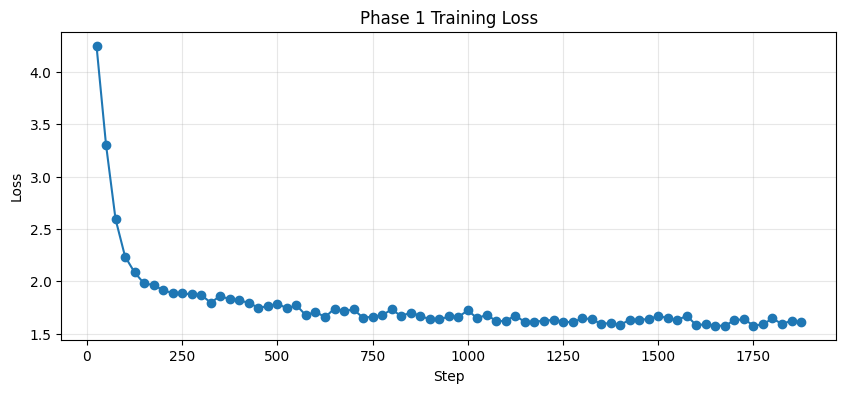

Saved figure: reports/figures/phase1_training_loss.png


In [16]:
import json
import pandas as pd
import matplotlib.pyplot as plt

log_path = Path('reports/metrics/training_log.json')
payload = json.loads(log_path.read_text(encoding='utf-8'))
history = pd.DataFrame(payload['log_history'])
display(history.tail())

loss_rows = history.dropna(subset=['loss']) if 'loss' in history.columns else pd.DataFrame()
if not loss_rows.empty:
    plt.figure(figsize=(10, 4))
    plt.plot(loss_rows['step'], loss_rows['loss'], marker='o')
    plt.title('Phase 1 Training Loss')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    figure_path = Path('reports/figures/phase1_training_loss.png')
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(figure_path, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved figure:', figure_path)

## 13. Evaluate Phase 1

Cell này tạo config evaluate tạm cho model `v1`, chạy ROUGE trên test set Colab, rồi lưu metrics/predictions vào `reports`.

### Phase 1 Result Summary

Ket qua Phase 1:
- `ROUGE-1`: `0.5520`
- `ROUGE-2`: `0.2333`
- `ROUGE-L`: `0.3449`

Day la muc ket qua kha tot cho mot mo hinh tom tat tieng Viet fine-tune tren subset Colab. Dac biet, `ROUGE-2` tren `0.23` cho thay mo hinh da hoc duoc khong chi tu khoa don le ma con giu duoc kha nhieu cum tu va quan he ngu nghia ngan trong summary.


In [17]:
with open('configs/eval.yaml', 'r', encoding='utf-8') as file:
    eval_cfg = yaml.safe_load(file)

eval_phase1_cfg = deepcopy(eval_cfg)
eval_phase1_cfg['model']['name'] = 'models/vit5-summarizer-v1'
eval_phase1_cfg['model']['fallback_name'] = 'VietAI/vit5-base'
eval_phase1_cfg['dataset']['test_file'] = 'data/processed/test_colab.jsonl'
eval_phase1_cfg['dataset']['max_samples'] = EVAL_LIMIT
eval_phase1_cfg['outputs']['metrics_file'] = 'reports/metrics/eval_phase1.json'
eval_phase1_cfg['outputs']['predictions_file'] = 'reports/examples/test_predictions_phase1.jsonl'

eval_phase1_path = Path('configs/_colab_eval_phase1.yaml')
with eval_phase1_path.open('w', encoding='utf-8') as file:
    yaml.safe_dump(eval_phase1_cfg, file, allow_unicode=True, sort_keys=False)

!python scripts/evaluate.py --config configs/_colab_eval_phase1.yaml
!cat reports/metrics/eval_phase1.json

2026-05-11 10:45:23.732125: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-11 10:45:32,476 | INFO | __main__ | Generating predictions for 200 examples.
2026-05-11 10:50:31,692 | INFO | absl | Using default tokenizer.
2026-05-11 10:50:32,043 | INFO | __main__ | Evaluation completed: {'rouge1': 0.552, 'rouge2': 0.2333, 'rougeL': 0.3449, 'rougeLsum': 0.3449}
{
  "rouge1": 0.552,
  "rouge2": 0.2333,
  "rougeL": 0.3449,
  "rougeLsum": 0.3449
}

In [18]:
prediction_path = Path('reports/examples/test_predictions_phase1.jsonl')
rows = [json.loads(line) for line in prediction_path.read_text(encoding='utf-8').splitlines()[:3]]

for i, row in enumerate(rows, start=1):
    print('=' * 90)
    print('Sample', i)
    print('\nDocument:', row['document'][:700])
    print('\nReference:', row['reference'])
    print('\nPrediction:', row['prediction'])
    print('\nError tags:', row['error_tags'])

Sample 1

Document: Theo lời khai của Huy tại phiên_toà, để có tiền sử_dụng cá_nhân, Huy " nổ " là sĩ_quan cục Phòng_chống ma_tuý của bộ Công_an đóng tại TP. Đà_Nẵng, có nguồn mua ô_tô thanh_lý giá rẻ, và khả_năng chạy việc vào ngành công_an. Chỉ với lời " nổ " này, từ tháng 10/2016 đến 9/2017, nhiều người đã bị lừa_đảo với tổng_số tiền 3,2 tỷ đồng. Trong đó, người bị Huy lừa nhiều nhất là vợ_chồng ông Bảo_Th., ngụ quận Hải_Châu. Huy giới_thiệu với cặp vợ_chồng này mình có suất mua ô_tô thanh_lý giá rẻ và rủ họ mua cùng. Tin lời, vợ_chồng ông Th. đưa cho Huy hơn 1 tỷ đồng. Cùng thủ_đoạn, Huy lừa thêm ông Nguyễn_Tấn_T. 970 triệu đồng, Lê_Quốc_Th. 400 triệu đồng, Trần_Nhật_S. 300 triệu đồng … Sau chiêu_thức mua x

Reference: Ngày 25/2, TAND TP. Đà_Nẵng tuyên_phạt Hồ_Xuân_Huy ( SN 1994 ), ngụ quận Hải_Châu, 12 năm tù về tội Lừa_đảo chiếm_đoạt tài_sản.

Prediction: Nhiều người bị Huy " nổ " là sĩ_quan cục Phòng_chống ma_tuý của bộ Công_an đóng tại TP. Đà_Nẵng, có nguồn mua ô_tô thanh_lý gi

## 14. Phase 1 Prediction After Training

Cell này dùng checkpoint `v1` để sinh summary cho sample ban đầu. Đây là nơi so sánh nhanh baseline vs fine-tuned model.

### Qualitative Insight

Sau fine-tuning, output Phase 1 ro rang mach lac hon baseline va bam noi dung document tot hon. Tuy nhien prediction van co xu huong thien ve mo ta dien bien thay vi luon tom dung vao ket qua phap ly hoac ket luan chinh nhu reference. Day la mot kieu loi dang ghi nhan trong phan error analysis: model hieu chu de chinh nhung doi luc chua uu tien dung diem ket luan quan trong nhat.


In [19]:
app_phase1_cfg = yaml.safe_load(Path('configs/app.yaml').read_text(encoding='utf-8'))
app_phase1_cfg['model']['name'] = 'models/vit5-summarizer-v1'
app_phase1_cfg['model']['fallback_name'] = 'VietAI/vit5-base'
app_phase1_path = Path('configs/_colab_app_phase1.yaml')
app_phase1_path.write_text(yaml.safe_dump(app_phase1_cfg, allow_unicode=True, sort_keys=False), encoding='utf-8')

!python scripts/predict.py --text-file reports/examples/colab_sample_input.txt --mode concise --length medium --config configs/_colab_app_phase1.yaml

2026-05-11 10:50:40.330451: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Nhiều người bị Huy " nổ " là sĩ_quan cục Phòng_chống ma_tuý của bộ Công_an đóng tại TP. Đà_Nẵng, có nguồn mua ô_tô thanh_lý giá rẻ và khả_năng chạy việc vào ngành công_an.

Keywords: huy, đồng, ông, công, mua, lừa, chồng, triệu
Quality Estimate: 87.23%
Latency: 1867 ms


## 15. Build And Inspect Synthetic Data For Phase 2

Phase 2 giúp model học các output mode như `concise`, `bullet`, `action_items`, `study_notes`. Dataset synthetic hiện được mở rộng lên 200 reviewed samples, chia đều 50 mẫu cho mỗi mode và split thành 160 train / 40 validation.


### Dataset Note

Synthetic dataset Phase 2 dùng để học controllability theo mode và giảm domain gap với meeting / lecture notes. ROUGE trên VietNews vẫn là metric summarization chung; phần compare-modes là đánh giá quan trọng hơn cho mục tiêu sản phẩm của Phase 2.


In [ ]:
!python scripts/build_phase2_synthetic_200.py
!python scripts/generate_synthetic.py --input data/synthetic/reviewed_all.json

from collections import Counter

reviewed = json.loads(Path('data/synthetic/reviewed_all.json').read_text(encoding='utf-8'))
print('reviewed_all:', len(reviewed))
print('reviewed modes:', dict(Counter(row['mode'] for row in reviewed)))
print('reviewed domains:', dict(Counter(row['domain'] for row in reviewed)))

for file_name in ['data/synthetic/train.jsonl', 'data/synthetic/validation.jsonl']:
    rows = [json.loads(line) for line in Path(file_name).read_text(encoding='utf-8').splitlines() if line.strip()]
    print('\n', file_name, len(rows))
    print('modes:', dict(Counter(row['mode'] for row in rows)))
    print('domains:', dict(Counter(row['domain'] for row in rows)))
    print('sample:', rows[0])


## 16. Train Phase 2

Chạy cell này sau khi `models/vit5-summarizer-v1` đã tồn tại. Phase 2 load checkpoint v1 rồi lưu checkpoint mới vào `models/vit5-summarizer-v2`.

In [21]:
!test -d models/vit5-summarizer-v1 && echo 'Phase 1 checkpoint exists.'
!python scripts/train_phase2.py --config configs/train_phase2.yaml

Phase 1 checkpoint exists.
2026-05-11 10:50:58.294461: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Map: 100% 3/3 [00:00<00:00, 328.20 examples/s]
Map: 100% 1/1 [00:00<00:00, 285.27 examples/s]
/content/smart-vietnamese-summarizer/scripts/train_phase2.py:116: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
 50% 1/2 [00:01<00:01,  1.07s/it]
                                 
{'eval_loss': 3.159181833267212, 'eval_rouge1': 0.4906, 'eval_rouge2': 0.0392, 'eval_rougeL': 0.3019, 'eval_rougeLsum': 0.3019, 'eval_runtime': 0.8526, 'eval_samples_per_second': 1.173, 'eval_steps_per_second': 1.173, 'epoch': 1.0}
 50% 1/2 [00:01<00:01,  

## 17. Evaluate Phase 2

Config mặc định `configs/eval.yaml` đang trỏ tới `models/vit5-summarizer-v2`. Cell này evaluate model phase 2 trên cùng test set Colab để có số so sánh.

### Phase 2 Result Summary

Sau khi rerun Phase 2 với 200 synthetic samples, điền lại metrics mới từ `reports/metrics/eval_phase2.json`.

Cách đọc kết quả:
- Nếu ROUGE Phase 2 giảm nhẹ so với Phase 1, điều đó vẫn có thể chấp nhận được vì Phase 2 tối ưu thêm controllability theo mode.
- Nếu output giữa 4 mode khác nhau hợp lý, Phase 2 đã đạt mục tiêu sản phẩm quan trọng.
- Nếu output quá giống nhau giữa các mode, ưu tiên review synthetic data và chạy thêm qualitative evaluation trước khi chỉnh hyperparameters.


In [22]:
eval_phase2_cfg = deepcopy(eval_cfg)
eval_phase2_cfg['model']['name'] = 'models/vit5-summarizer-v2'
eval_phase2_cfg['model']['fallback_name'] = 'models/vit5-summarizer-v1'
eval_phase2_cfg['dataset']['test_file'] = 'data/processed/test_colab.jsonl'
eval_phase2_cfg['dataset']['max_samples'] = EVAL_LIMIT
eval_phase2_cfg['outputs']['metrics_file'] = 'reports/metrics/eval_phase2.json'
eval_phase2_cfg['outputs']['predictions_file'] = 'reports/examples/test_predictions_phase2.jsonl'

eval_phase2_path = Path('configs/_colab_eval_phase2.yaml')
with eval_phase2_path.open('w', encoding='utf-8') as file:
    yaml.safe_dump(eval_phase2_cfg, file, allow_unicode=True, sort_keys=False)

!python scripts/evaluate.py --config configs/_colab_eval_phase2.yaml
!cat reports/metrics/eval_phase2.json

2026-05-11 10:52:20.539123: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-11 10:52:30,285 | INFO | __main__ | Generating predictions for 200 examples.
2026-05-11 10:57:39,805 | INFO | absl | Using default tokenizer.
2026-05-11 10:57:40,160 | INFO | __main__ | Evaluation completed: {'rouge1': 0.5476, 'rouge2': 0.2271, 'rougeL': 0.3427, 'rougeLsum': 0.3427}
{
  "rouge1": 0.5476,
  "rouge2": 0.2271,
  "rougeL": 0.3427,
  "rougeLsum": 0.3427
}

## 18. Compare Modes After Phase 2

Một input, bốn mode. Đây là phần rất hay để đưa vào demo/report vì nó cho thấy product behavior, không chỉ metric.

### Demo Interpretation

Nếu các mode `concise`, `bullet`, `action_items`, và `study_notes` tạo ra output khác nhau một cách hợp lý, thì đây là thành công quan trọng của Phase 2 ở góc nhìn sản phẩm. Trong project này, controllability là mục tiêu riêng song song với ROUGE, nên phần compare-modes rất đáng đưa vào báo cáo và demo.


In [ ]:
# Quick single-input comparison for live demo
for mode in ['concise', 'bullet', 'action_items', 'study_notes']:
    print('\n' + '=' * 90)
    print('MODE:', mode)
    subprocess.run(
        [
            'python',
            'scripts/predict.py',
            '--text-file',
            'reports/examples/colab_sample_input.txt',
            '--mode',
            mode,
            '--length',
            'medium',
            '--config',
            'configs/app.yaml',
        ],
        check=True,
    )

# Batch qualitative comparison: 10 inputs x 4 modes
!python scripts/evaluate_modes.py --input data/samples/qualitative_mode_eval.jsonl --length medium --output reports/examples/mode_comparison_predictions.jsonl
!head -20 reports/examples/mode_comparison_predictions.jsonl


## 19. Collect Final Artifacts

Vì `models` và `reports` đã link sang Drive, artifact đã được lưu tự động. Cell này chỉ in lại vị trí để bạn dễ mở từ Drive.

In [24]:
print('Artifacts in Drive:')
print(ARTIFACT_DIR)

print('\nModels:')
!find models -maxdepth 2 -type f | head -30

print('\nReports:')
!find reports -maxdepth 3 -type f | sort

Artifacts in Drive:
/content/drive/MyDrive/smart-vietnamese-summarizer-artifacts

Models:

Reports:


## 20. What To Write In The Report

Sau khi chạy xong notebook, ghi lại các ý này vào report:
- Dataset dùng để train Phase 1: VietNews, split train/validation/test sau khi giới hạn Colab.
- Dataset dùng cho Phase 2: 200 reviewed synthetic samples, 160 train / 40 validation, 50 samples per mode.
- Model base: `VietAI/vit5-base`.
- Phase 1 config: batch size, gradient accumulation, max source length, max target length, epochs.
- Phase 2 config: `epochs=2`, `learning_rate=1e-5`, `gradient_accumulation_steps=4`, synthetic multi-mode prefixes.
- Smoke test pass hay lỗi gì.
- Phase 1 training loss và validation loss.
- ROUGE Phase 1 và Phase 2 nếu có.
- 3 sample prediction: document preview, reference, prediction, nhận xét lỗi.
- Với Phase 2, so sánh output giữa `concise`, `bullet`, `action_items`, `study_notes` bằng `mode_comparison_predictions.jsonl`.

Kết luận mong muốn: model đã chạy được pipeline fine-tuning tiếng Việt end-to-end, Phase 1 học summarization core, Phase 2 học controllable modes tốt hơn nhờ synthetic data lớn và cân bằng hơn.


## Final Notebook Conclusion

Notebook 02 cho thấy toàn bộ training pipeline có thể chạy trên Colab T4:
- Phase 1 fine-tuning trên VietNews tạo nền tảng summarization tiếng Việt.
- Phase 2 fine-tuning trên 200 synthetic samples bổ sung khả năng điều khiển output theo mode.
- ROUGE dùng để so sánh chất lượng summarization chung, còn mode comparison dùng để đánh giá controllability.

Kết luận phù hợp cho report là: **Phase 1 là nền tảng chất lượng chính, còn Phase 2 là bước domain/style adaptation để sản phẩm hỗ trợ nhiều kiểu output hơn.**


## Troubleshooting Quick Notes

- `No module named smart_summarizer`: kiểm tra đang ở đúng repo root bằng `!pwd`, rồi chạy lại script từ root.
- `CUDA out of memory`: giảm batch size hoặc `max_source_length` trong config Colab.
- `HF Hub unauthenticated`: có thể bỏ qua, hoặc login Hugging Face token.
- Colab disconnect: chạy lại notebook; checkpoint và processed data vẫn nằm trong Drive.
- `models/vit5-summarizer-v1` không tồn tại trước Phase 2: chạy xong Phase 1 trước.
- Metrics quá thấp: kiểm tra sample prediction, không chỉ nhìn ROUGE. Với summarization tiếng Việt, qualitative review rất quan trọng.